# Projeto 2 - Jacobi e Gauss-Seidel

Modelo de entrega.

Respeite as divisões em Markdown para facilitar a navegação no relatório.

## Questão 1a: Implementação

Implemente os métodos de Jacobi e Gauss-Seidel para resolver o sistema linear $Ax = b$.

In [1]:
# Código
using LinearAlgebra

nothing


In [2]:
function produtorio_sem_i(v::AbstractArray, u::Vector, pos)
    return v' * u - v[pos] * u[pos]
end

function norma(v::Vector)
    return sqrt(v' * v)
end

nothing


In [3]:
function JacobiConverge(A::Matrix)
    if any(diag(A) .== 0)
        return Inf
    end
    
    D = Diagonal(diag(A))

    Mj = D \ (A - D)

    return norm(Mj, Inf)
end

nothing

In [4]:

function novo_chute_jacobi!(A::Matrix, v::Vector, cur::Vector, chute::Vector, pos::Int, m::Int)
    chute[pos] = (v[pos] - produtorio_sem_i(@views(A[pos, :]), cur, pos)) / A[pos, pos]
end

function Jacobi(A::Matrix, v::Vector, eps)
    chute::Vector = zeros(size(v,1))
    cur::Vector = copy(chute)
    m, n = size(A)
    erros = Float64[]

    for _ in 1:1000
        for i in 1:m
            novo_chute_jacobi!(A, v, cur, chute, i, m)
        end
        push!(erros, norma(A * chute - v))
        if erros[end] < eps
            return chute, erros
        end
        cur = copy(chute)
    end
    return chute, erros
end

nothing

In [5]:
function GaussSeidelConverge(A::Matrix)
    if any(diag(A) .== 0)
        return Inf
    end

    LD = tril(A)

    Mgs = LD \ (A - LD)

    return norm(Mgs, Inf)
end

nothing

In [6]:

function novo_chute_gs!(A::Matrix, v::Vector, chute::Vector, pos::Int, m::Int)
    chute[pos] = (v[pos] - produtorio_sem_i(@views(A[pos, :]), chute, pos)) / A[pos, pos]
end

function GaussSiedel(A::Matrix, v::Vector, eps)
    chute::Vector = zeros(size(v,1))
    m, n = size(A)
    erros = Float64[]

    for _ in 1:1000
        for i in 1:m
            novo_chute_gs!(A, v, chute, i, m)
        end
        push!(erros, norma(A * chute - v))
        if erros[end] < eps
            return chute, erros
        end
    end
    return chute, erros
end

nothing


Qual deveria ser a complexidade computacional do código que você escreveu?

O($n^2$)


## Questão 1b: Testes
Teste com matrizes $2 \times 2$ e $3 \times 3$, e compare graficamente a velocidade de convergência dos dois métodos.

In [7]:
# gráficos
using Plots

function grafico(JE::Vector, GsE::Vector)
    plot(1:length(JE), JE, marker=:circle, label="Jacobi", xlabel="Iteração", ylabel="Erro")
    plot!(1:length(GsE), GsE, marker=:diamond, label="Gauss-Seidel")
end

nothing


In [8]:
function test_matrix(A::Matrix, v::Vector)
    J, JE   = Jacobi(A, v, 10^(-12))
    Gs, GsE = GaussSiedel(A, v, 10^(-12))
    
    grafico(JE, GsE)
end

function test_random_matrix(m::Int)
    A = rand(m,m) + 2* I(m)
    v = rand(m)
    
    test_matrix(A, v)
end

nothing


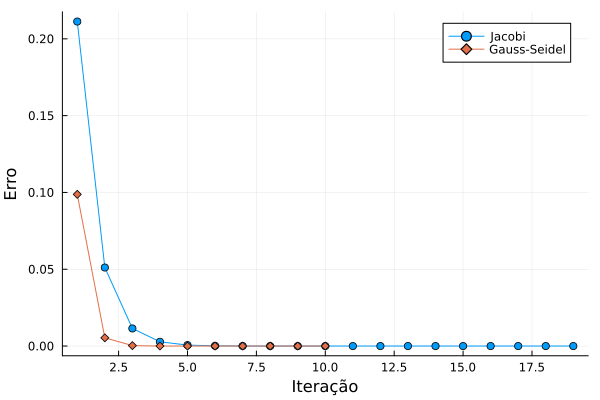

In [9]:
test_random_matrix(2)


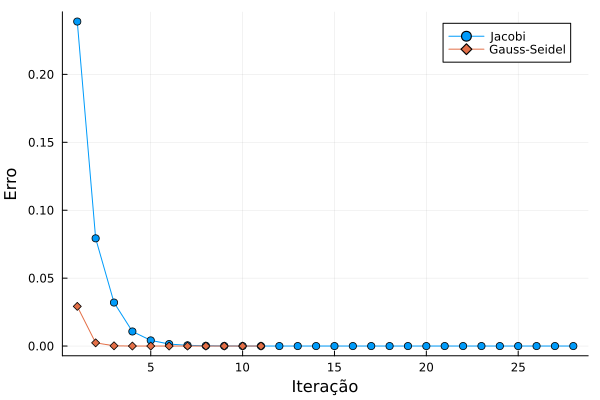

In [10]:
test_random_matrix(3)

Gauss converge mais rápido geralmente

## Questão 1c: Matrizes maiores
Teste com matrizes maiores.  Estes métodos funcionam para matrizes do tipo `rand(m,m)`?

In [11]:

function testar_se_matriz_converge(A::Matrix)
    J = JacobiConverge(A) < 1
    Gs = GaussSeidelConverge(A) < 1
    return J && Gs
end

function testar_matrizes(f, tamanho::Int)
    d = Dict("verdadeiro" => 0, "falso" => 0)
    for j in 1:100
        if testar_se_matriz_converge(f(tamanho))
            d["verdadeiro"] += 1
        else
            d["falso"] += 1
        end
    end
    return d
end

nothing

In [12]:
function randomico(m)
    return rand(m,m)
end

for i in 4:20
    println(testar_matrizes(randomico, i))
end

Dict("falso" => 100, "verdadeiro" => 0)
Dict("falso" => 100, "verdadeiro" => 0)
Dict("falso" => 100, "verdadeiro" => 0)
Dict("falso" => 100, "verdadeiro" => 0)
Dict("falso" => 100, "verdadeiro" => 0)
Dict("falso" => 100, "verdadeiro" => 0)
Dict("falso" => 100, "verdadeiro" => 0)
Dict("falso" => 100, "verdadeiro" => 0)
Dict("falso" => 100, "verdadeiro" => 0)
Dict("falso" => 100, "verdadeiro" => 0)
Dict("falso" => 100, "verdadeiro" => 0)
Dict("falso" => 100, "verdadeiro" => 0)
Dict("falso" => 100, "verdadeiro" => 0)
Dict("falso" => 100, "verdadeiro" => 0)
Dict("falso" => 100, "verdadeiro" => 0)
Dict("falso" => 100, "verdadeiro" => 0)
Dict("falso" => 100, "verdadeiro" => 0)


Majoritariamente não

## Questão 1d: Matrizes maiores ainda!
Quão grande deve ser $k(m)$ para funcionar para 95\% das matrizes do tipo `randn(m,m)` + $ k(m) \cdot I_m$?  Quais velocidades de convergência você observa para este $k(m)$?

In [13]:
# Código (gerando possivelmente gráficos ou tabelas)

function k(m)
    return 2 * sqrt( (m) * ( 1 - 2/3.14159))
end

function makerand(m)
    return randn(m,m) + k(m) * I(m)
end

for i in 15:100
    println(testar_matrizes(makerand, i))
end

nothing


Dict("falso" => 20, "verdadeiro" => 80)
Dict("falso" => 20, "verdadeiro" => 80)
Dict("falso" => 20, "verdadeiro" => 80)
Dict("falso" => 11, "verdadeiro" => 89)
Dict("falso" => 15, "verdadeiro" => 85)
Dict("falso" => 10, "verdadeiro" => 90)
Dict("falso" => 11, "verdadeiro" => 89)
Dict("falso" => 8, "verdadeiro" => 92)
Dict("falso" => 3, "verdadeiro" => 97)
Dict("falso" => 1, "verdadeiro" => 99)
Dict("falso" => 6, "verdadeiro" => 94)
Dict("falso" => 6, "verdadeiro" => 94)
Dict("falso" => 2, "verdadeiro" => 98)
Dict("falso" => 0, "verdadeiro" => 100)
Dict("falso" => 1, "verdadeiro" => 99)
Dict("falso" => 2, "verdadeiro" => 98)
Dict("falso" => 0, "verdadeiro" => 100)
Dict("falso" => 1, "verdadeiro" => 99)
Dict("falso" => 1, "verdadeiro" => 99)
Dict("falso" => 1, "verdadeiro" => 99)
Dict("falso" => 1, "verdadeiro" => 99)
Dict("falso" => 0, "verdadeiro" => 100)
Dict("falso" => 0, "verdadeiro" => 100)
Dict("falso" => 0, "verdadeiro" => 100)
Dict("falso" => 0, "verdadeiro" => 100)
Dict("falso"

(Comentários)

## Questão 1e: Jacobi vs Gauss-Seidel
Encontre uma matriz $A$ $4 \times 4$ para a qual o método de Jacobi tenha melhor convergência que o método de Gauss-Seidel.

(Explique suas ideias, verifique abaixo)

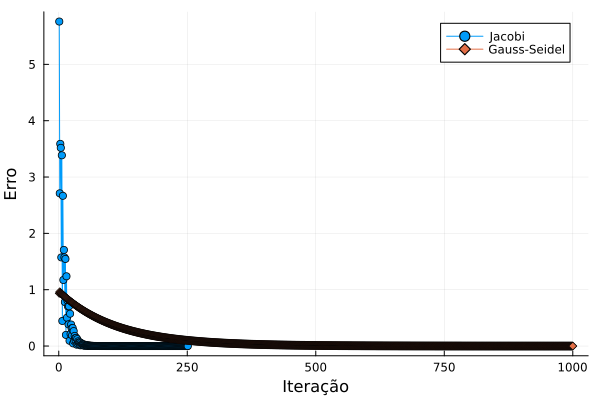

In [ ]:
# Código


JacobiFaster = [ 2 1 0 1
                 0 2 1 1 
                 0 0 2 10
                 -1 -10 -10 83
                ]

println(JacobiConverge(JacobiFaster))

test_matrix(JacobiFaster, rand(4))

## Questão 1f: Perturbações
O que acontece se você somar uma matriz aleatória e pequena à matriz $A$ acima?  O que acontece se esta perturbação acontecer apenas fora da diagonal?

In [16]:
# Código

(Comentários)